In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv("titanic.csv")

print(df.head())
print(df.shape)
print(df.columns)

   PassengerId  Pclass             Name     Sex  Age  SibSp  Parch  \
0            1       3     Allison Hill    male   17      4      2   
1            2       1      Noah Rhodes    male   60      2      2   
2            3       3  Angie Henderson    male   64      0      0   
3            4       3    Daniel Wagner    male   35      4      0   
4            5       1  Cristian Santos  female   70      0      3   

                                 Ticket    Fare Embarked  Survived  
0  43d75413-a939-4bd1-a516-b0d47d3572cc  144.08        Q         1  
1  6334fa2a-8b4b-47e7-a451-5ae01754bf08  249.04        S         0  
2  61a66444-e2af-4629-9efb-336e2f546033   50.31        Q         1  
3  0b6c03c8-721e-4419-afc3-e6495e911b91  235.20        C         1  
4  436e3c49-770e-49db-b092-d40143675d58  160.17        C         1  
(1000, 11)
Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Embarked', 'Survived'],
      dtype='object')


In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Fare"] = df["Fare"].fillna(df["Fare"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [ ]:
le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])

In [ ]:
X = df.drop(["Survived", "Name", "Ticket"], axis=1)
y = df["Survived"]

print(X.head())

   PassengerId  Pclass  Sex  Age  SibSp  Parch    Fare  Embarked
0            1       3    1   17      4      2  144.08         1
1            2       1    1   60      2      2  249.04         2
2            3       3    1   64      0      0   50.31         1
3            4       3    1   35      4      0  235.20         0
4            5       1    0   70      0      3  160.17         0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (800, 8)
Testing: (200, 8)


In [ ]:
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
y_pred = model.predict(X_test)

print("Predicted values:")
print(y_pred)

Predicted values:
[1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 0 1 0 1 1 1 0 1 1 1 1 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 0 0 1 1 1 1 1 0 1 1 1
 0 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1 1 1
 1 1 0 0 0 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 0 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy:", accuracy)

Decision Tree Accuracy: 0.52


In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.21      0.30       102
           1       0.51      0.85      0.63        98

    accuracy                           0.52       200
   macro avg       0.54      0.53      0.47       200
weighted avg       0.55      0.52      0.47       200



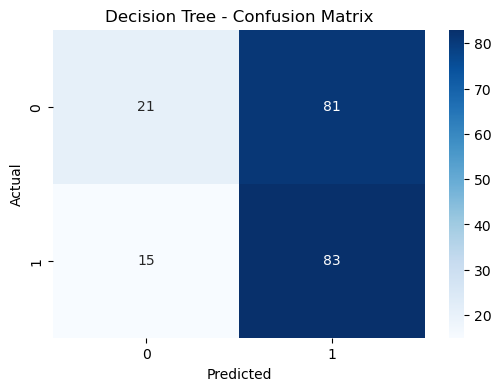

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

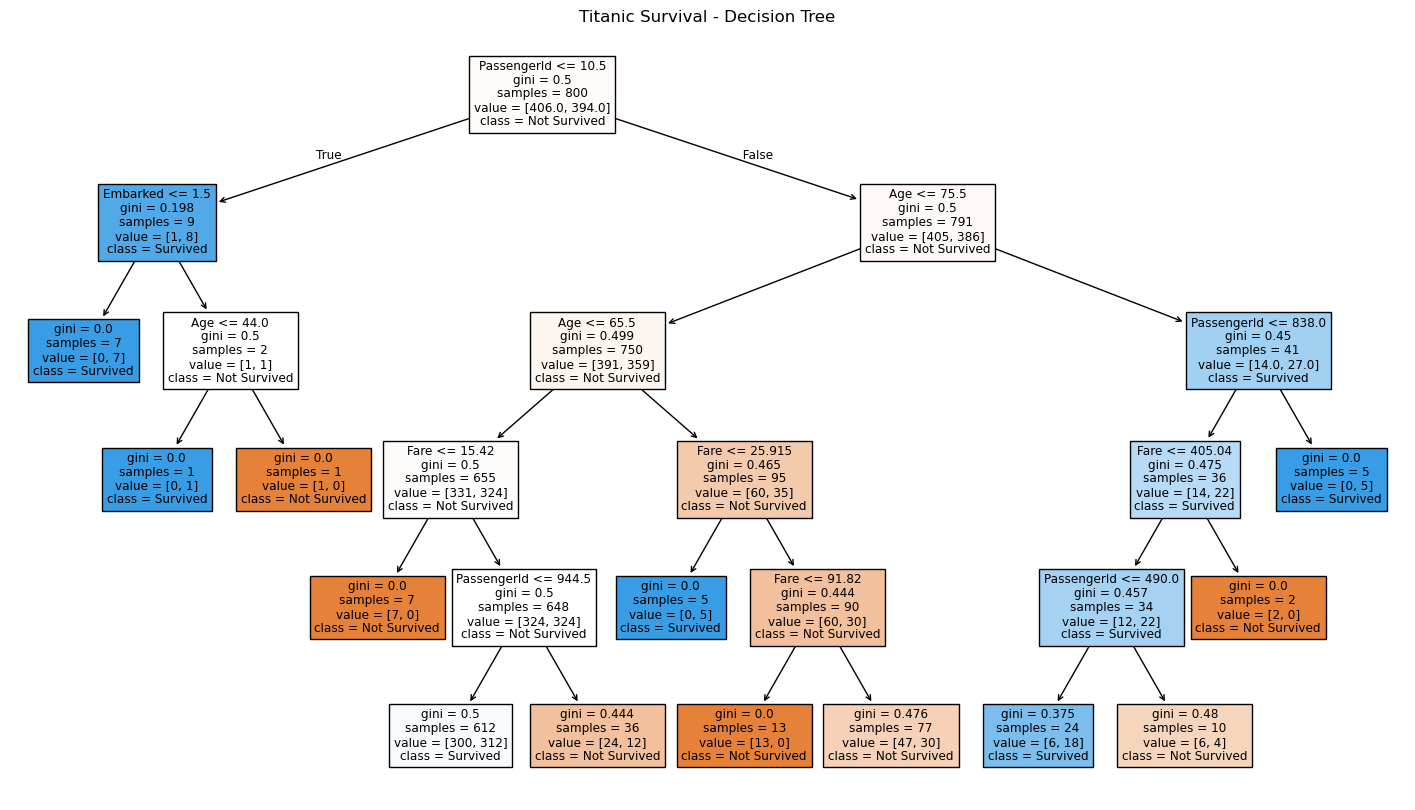

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True
)

plt.title("Titanic Survival - Decision Tree")
plt.show()

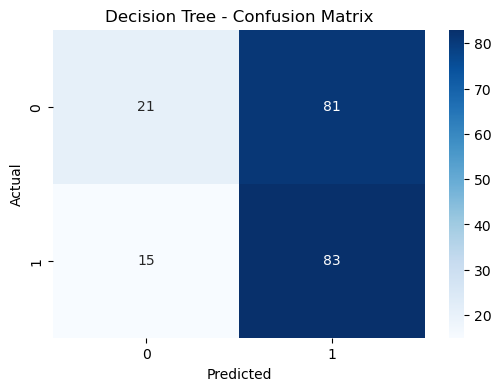

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")
plt.show()